N images: 3000
Ambient dimension: 3072
PR(original cats):      9.47
PR(cats + random border): 274.37


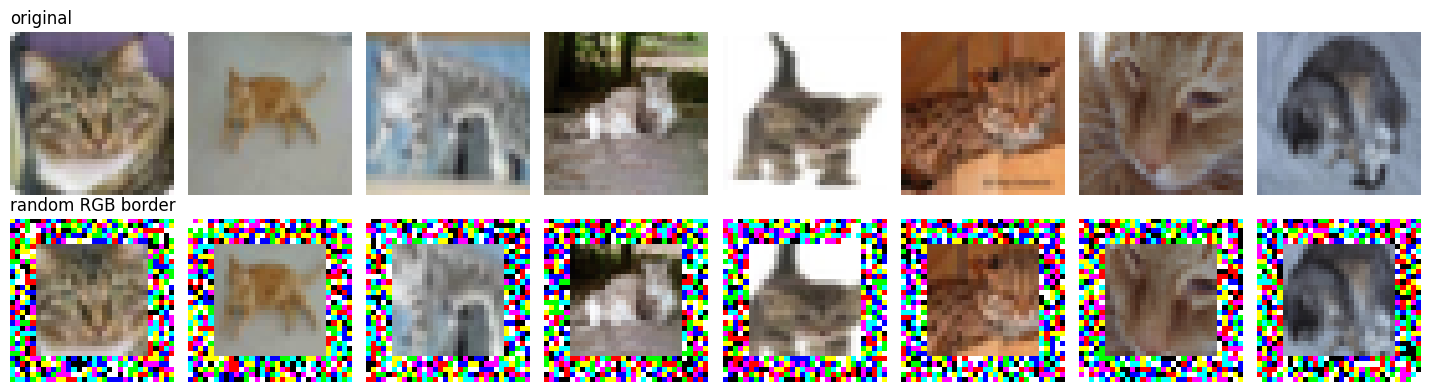

In [9]:
# Compact Colab cell: PR of CIFAR-10 cats before/after a thick random RGB border

import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# -----------------------
# Settings
# -----------------------
SEED = 0
N_CATS = 3000
BORDER_THICKNESS = 5   # fairly thick for 32x32 CIFAR
SHOW = 8

rng = np.random.default_rng(SEED)

# -----------------------
# Load CIFAR-10 cat images
# -----------------------
trainset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transforms.ToTensor())
cat_label = trainset.class_to_idx["cat"]
cat_indices = [i for i, (_, y) in enumerate(trainset) if y == cat_label][:N_CATS]

X = np.stack([trainset[i][0].permute(1,2,0).numpy() for i in cat_indices], axis=0).astype(np.float32)
N, H, W, C = X.shape

# -----------------------
# Participation Ratio
# -----------------------
def participation_ratio(images):
    Xflat = images.reshape(images.shape[0], -1).astype(np.float64)
    Xflat -= Xflat.mean(axis=0, keepdims=True)
    s = np.linalg.svd(Xflat, full_matrices=False, compute_uv=False)
    lam = s**2
    return float((lam.sum()**2) / np.sum(lam**2))

# -----------------------
# Thick border mask
# -----------------------
mask = np.zeros((H, W), dtype=bool)
t = BORDER_THICKNESS
mask[:t, :] = True
mask[-t:, :] = True
mask[:, :t] = True
mask[:, -t:] = True
mask4 = mask[None, :, :, None]

# -----------------------
# Best perturbation:
# independent binary RGB noise on border
# -----------------------
noise = rng.integers(0, 2, size=X.shape).astype(np.float32)   # each RGB channel independently 0 or 1
X_border = np.where(mask4, noise, X)

# -----------------------
# Compute PR
# -----------------------
pr_original = participation_ratio(X)
pr_border   = participation_ratio(X_border)

print(f"N images: {N}")
print(f"Ambient dimension: {H*W*C}")
print(f"PR(original cats):      {pr_original:.2f}")
print(f"PR(cats + random border): {pr_border:.2f}")

# -----------------------
# Show examples
# -----------------------
idx = rng.choice(N, size=SHOW, replace=False)
fig, axes = plt.subplots(2, SHOW, figsize=(1.8*SHOW, 4))

for j, i in enumerate(idx):
    axes[0, j].imshow(X[i])
    axes[0, j].axis("off")
    if j == 0:
        axes[0, j].set_title("original", loc="left", fontsize=12)

    axes[1, j].imshow(X_border[i])
    axes[1, j].axis("off")
    if j == 0:
        axes[1, j].set_title("random RGB border", loc="left", fontsize=12)

plt.tight_layout()
plt.show()